# 12. Analysis: Human Evaluation

This notebook is the production-ready human-evaluation analysis notebook for the DATASCI 266 idiom-aware machine translation project.

It is aligned with the frozen project state:

- Notebook 30 remains the source of truth for automatic metrics
- Notebook 11 remains the finalized automatic-metrics analysis notebook
- Notebook 21 remains frozen
- This notebook analyzes the completed human evaluation and compares it against the finalized COMET results where appropriate

## Scope

- Load the completed blinded annotation file and private output mapping
- Unblind model identities for the fixed 6-model human-eval subset
- Produce paper-ready summary tables overall and by split
- Analyze explicit preferences, ties, and pairwise comparisons
- Compare human-eval rankings against finalized COMET results from `automatic_plus_comet.csv`
- Export all artifacts needed for paper integration



# 0. Mount Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup


In [2]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_DIR = Path('/content/drive/MyDrive/ds266_idiom_mt')
QUAL_PREDS_DIR = PROJECT_DIR / 'qual_preds'
RESULTS_DIR = PROJECT_DIR / 'results'
EXPORT_DIR = RESULTS_DIR / 'human_eval_outputs'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    'human_eval_annotations': QUAL_PREDS_DIR / 'preds_6models_annotation_v3_blinded_MStrommer.csv',
    'human_eval_mapping': QUAL_PREDS_DIR / 'preds_6models_annotation_v3_mapping_PRIVATE.json',
    'selected_examples': QUAL_PREDS_DIR / 'preds_6models_annotation_v3_selected_examples.csv',
    'unblinded_preview': QUAL_PREDS_DIR / 'preds_6models_annotation_v3_unblinded_preview.csv',
    'automatic_plus_comet': RESULTS_DIR / 'automatic_plus_comet.csv',
}

for name, path in FILES.items():
    print(f'{name}: {path} | exists={path.exists()}')
print(f'export_dir: {EXPORT_DIR} | exists={EXPORT_DIR.exists()}')

human_eval_annotations: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_6models_annotation_v3_blinded_MStrommer.csv | exists=True
human_eval_mapping: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_6models_annotation_v3_mapping_PRIVATE.json | exists=True
selected_examples: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_6models_annotation_v3_selected_examples.csv | exists=True
unblinded_preview: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/preds_6models_annotation_v3_unblinded_preview.csv | exists=True
automatic_plus_comet: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_plus_comet.csv | exists=True
export_dir: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs | exists=True


## 2. Load data sources


In [3]:
missing_required = [name for name in ['human_eval_annotations', 'human_eval_mapping', 'selected_examples', 'automatic_plus_comet'] if not FILES[name].exists()]
if missing_required:
    raise FileNotFoundError(f'Missing required files: {missing_required}')

annotations_raw = pd.read_csv(FILES['human_eval_annotations'])
with open(FILES['human_eval_mapping'], 'r') as f:
    mapping_json = json.load(f)

selected_examples = pd.read_csv(FILES['selected_examples'])
unblinded_preview = pd.read_csv(FILES['unblinded_preview']) if FILES['unblinded_preview'].exists() else None
automatic_metrics = pd.read_csv(FILES['automatic_plus_comet'])

print('Loaded successfully.')
print('annotations_raw:', annotations_raw.shape)
print('selected_examples:', selected_examples.shape)
print('automatic_metrics:', automatic_metrics.shape)
print('mapping models:', mapping_json['models'])

Loaded successfully.
annotations_raw: (50, 36)
selected_examples: (50, 17)
automatic_metrics: (20, 8)
mapping models: ['baseline', 'idiom_only_v1', 'lora_r4_stage2', 'lora_r8_stage2', 'lora_r16_stage2', 'flan_t5_small_prompt_0shot']


## 3. Input data validation

These checks confirm that the notebook is using the expected fixed six-model human-eval subset and the finalized automatic-metrics file.



In [4]:
expected_models = list(mapping_json['models'])
expected_model_set = set(expected_models)
mapping_by_example = mapping_json['mapping_by_example_id']

print('shuffle_per_example:', mapping_json.get('shuffle_per_example'))
print('seed:', mapping_json.get('seed'))
print('annotation groups:')
display(annotations_raw['group'].value_counts(dropna=False).rename_axis('group').reset_index(name='n_examples'))

print('rows in annotations:', len(annotations_raw))
print('unique example_ids:', annotations_raw['example_id'].nunique())
print('duplicate example_ids:', annotations_raw['example_id'].duplicated().sum())

print('selected_examples groups:')
display(selected_examples['group'].value_counts(dropna=False).rename_axis('group').reset_index(name='n_examples'))

print('automatic metrics splits:')
display(automatic_metrics['split'].value_counts(dropna=False).rename_axis('split').reset_index(name='n_rows'))

shuffle_per_example: True
seed: 42
annotation groups:


,group,n_examples
0,idioms_test,25
1,wmt_test,25


rows in annotations: 50
unique example_ids: 50
duplicate example_ids: 0
selected_examples groups:


,group,n_examples
0,idioms_test,25
1,wmt_test,25


automatic metrics splits:


,split,n_rows
0,idioms_test,10
1,wmt_test,10


In [5]:
# Check that the mapping covers every annotated example
missing_mapping = sorted(set(annotations_raw['example_id'].astype(str)) - set(mapping_by_example.keys()))
if missing_mapping:
    raise ValueError(f'Missing mapping entries for example_ids: {missing_mapping[:10]}')

# Check that selected examples are the expected 50-example packet
print('Expected 50 examples in selected_examples:', selected_examples['example_id'].nunique())
print('Expected 50 examples in annotations:', annotations_raw['example_id'].nunique())

# Restrict automatic metrics to the six-model human-eval subset for fair comparison
auto_subset = automatic_metrics.copy()
if 'model' in auto_subset.columns and 'model_label' not in auto_subset.columns:
    auto_subset = auto_subset.rename(columns={'model': 'model_label'})

auto_subset = auto_subset[auto_subset['model_label'].isin(expected_models)].copy()

print('Automatic metrics restricted to human-eval subset:')
display(auto_subset.sort_values(['split', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))

Expected 50 examples in selected_examples: 50
Expected 50 examples in annotations: 50
Automatic metrics restricted to human-eval subset:


,model_label,split,comet_mean,comet_std,n,bleu,chrf,metrics_source_file
0,idiom_only_v1,idioms_test,0.762717,0.133694,25,44.161210,64.438061,automatic_metrics_canonical.csv
1,lora_r16_stage2,idioms_test,0.732651,0.143304,25,41.724245,61.449820,automatic_metrics_canonical.csv
2,baseline,idioms_test,0.732551,0.135192,25,39.649352,60.786112,automatic_metrics_canonical.csv
3,lora_r8_stage2,idioms_test,0.732034,0.147128,25,42.178766,61.760909,automatic_metrics_canonical.csv
4,lora_r4_stage2,idioms_test,0.728579,0.152061,25,41.853197,61.836284,automatic_metrics_canonical.csv
5,flan_t5_small_prompt_0shot,idioms_test,0.381018,0.118532,25,8.126810,33.138795,automatic_metrics_canonical.csv
6,idiom_only_v1,wmt_test,0.863072,0.070707,25,26.540147,58.230959,automatic_metrics_canonical.csv
7,lora_r16_stage2,wmt_test,0.846875,0.094321,25,27.596422,58.459373,automatic_metrics_canonical.csv
8,lora_r8_stage2,wmt_test,0.842295,0.103735,25,27.480339,58.459796,automatic_metrics_canonical.csv
9,lora_r4_stage2,wmt_test,0.833291,0.114230,25,27.568797,58.493063,automatic_metrics_canonical.csv


## 4. Unblind and reshape annotations

The annotation packet is one row per example with six blinded outputs (`A` through `F`).  
This section maps each letter back to the true model label and reshapes the file into a long format suitable for analysis.



In [6]:
OUTPUT_LETTERS = list('ABCDEF')

def parse_best_output(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == 'none':
        return []
    parts = [p.strip().upper() for p in s.split(',') if p.strip()]
    return [p for p in parts if p in OUTPUT_LETTERS]

def parse_numeric(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    s = str(value).strip()
    if s == '':
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

rows = []

for _, row in annotations_raw.iterrows():
    example_id = int(row['example_id'])
    mapping = mapping_by_example[str(example_id)]
    selected_letters = parse_best_output(row.get('best_output'))
    selected_models = {mapping[f'output_{letter}'] for letter in selected_letters}

    for letter in OUTPUT_LETTERS:
        model_label = mapping[f'output_{letter}']
        adequacy = parse_numeric(row.get(f'adequacy_{letter}'))
        fluency = parse_numeric(row.get(f'fluency_{letter}'))
        idiom_correct = parse_numeric(row.get(f'idiom_correct_{letter}'))
        over_idiomatization = parse_numeric(row.get(f'over_idiomatization_{letter}'))

        rows.append({
            'annotator_file': FILES['human_eval_annotations'].name,
            'example_id': example_id,
            'group': row['group'],
            'source': row['source'],
            'reference': row['reference'],
            'model_label': model_label,
            'blinded_output_letter': letter,
            'adequacy': adequacy,
            'fluency': fluency,
            'mean_quality': np.nanmean([adequacy, fluency]),
            'idiom_correct': idiom_correct,
            'over_idiomatization': over_idiomatization,
            'idiom_eval_applicable': pd.notna(idiom_correct),
            'best_output_flag': model_label in selected_models,
            'n_best_selected_for_example': len(selected_models),
            'best_output_raw': row.get('best_output'),
            'notes': row.get('notes'),
        })

human_long = pd.DataFrame(rows)
human_long['model_label'] = pd.Categorical(human_long['model_label'], categories=expected_models, ordered=True)

print('human_long:', human_long.shape)
display(human_long.head())

human_long: (300, 17)


,annotator_file,example_id,group,source,reference,model_label,blinded_output_letter,adequacy,fluency,mean_quality,idiom_correct,over_idiomatization,idiom_eval_applicable,best_output_flag,n_best_selected_for_example,best_output_raw,notes
0,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",lora_r8_stage2,A,2.0,1.0,1.5,1.0,0.0,True,False,3,"B,C,E",F uses a mix of German and English
1,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",idiom_only_v1,B,2.0,2.0,2.0,1.0,0.0,True,True,3,"B,C,E",F uses a mix of German and English
2,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",lora_r4_stage2,C,2.0,2.0,2.0,1.0,0.0,True,True,3,"B,C,E",F uses a mix of German and English
3,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",lora_r16_stage2,D,2.0,1.0,1.5,1.0,0.0,True,False,3,"B,C,E",F uses a mix of German and English
4,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",baseline,E,2.0,1.0,1.5,1.0,0.0,True,True,3,"B,C,E",F uses a mix of German and English


In [7]:
# Bring in selected-example metadata and per-example COMET scores used during example selection
meta_cols = ['example_id', 'group', 'comet_max', 'comet_min', 'comet_range', 'selection_rank_within_group']
selected_meta = selected_examples[meta_cols].drop_duplicates().copy()

human_long = human_long.merge(
    selected_meta,
    on=['example_id', 'group'],
    how='left'
)

# Add per-example COMET score for the current model if available in selected_examples
if expected_model_set.issubset(selected_examples.columns):
    per_example_comet = selected_examples[['example_id', 'group'] + expected_models].melt(
        id_vars=['example_id', 'group'],
        value_vars=expected_models,
        var_name='model_label',
        value_name='example_comet'
    )
    human_long = human_long.merge(per_example_comet, on=['example_id', 'group', 'model_label'], how='left')
else:
    human_long['example_comet'] = np.nan

print('Merged metadata into human_long.')
display(human_long.head())

Merged metadata into human_long.


,annotator_file,example_id,group,source,reference,model_label,blinded_output_letter,adequacy,fluency,mean_quality,idiom_correct,over_idiomatization,idiom_eval_applicable,best_output_flag,n_best_selected_for_example,best_output_raw,notes,comet_max,comet_min,comet_range,selection_rank_within_group,example_comet
0,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",lora_r8_stage2,A,2.0,1.0,1.5,1.0,0.0,True,False,3,"B,C,E",F uses a mix of German and English,0.876986,0.290774,0.586211,4,0.827501
1,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",idiom_only_v1,B,2.0,2.0,2.0,1.0,0.0,True,True,3,"B,C,E",F uses a mix of German and English,0.876986,0.290774,0.586211,4,0.876986
2,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",lora_r4_stage2,C,2.0,2.0,2.0,1.0,0.0,True,True,3,"B,C,E",F uses a mix of German and English,0.876986,0.290774,0.586211,4,0.839807
3,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",lora_r16_stage2,D,2.0,1.0,1.5,1.0,0.0,True,False,3,"B,C,E",F uses a mix of German and English,0.876986,0.290774,0.586211,4,0.827501
4,preds_6models_annotation_v3_blinded_MStrommer.csv,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",baseline,E,2.0,1.0,1.5,1.0,0.0,True,True,3,"B,C,E",F uses a mix of German and English,0.876986,0.290774,0.586211,4,0.842750


## 5. Compared models

These are the six systems included in the fixed human-evaluation packet.



In [8]:
model_notes = pd.DataFrame({
    'model_label': expected_models,
    'family': [
        'Helsinki baseline',
        'Full fine-tune',
        'LoRA',
        'LoRA',
        'LoRA',
        'FLAN prompting',
    ],
    'notes': [
        'Pretrained EN→DE baseline',
        'Idiom-only fine-tune',
        'LoRA rank 4',
        'LoRA rank 8',
        'LoRA rank 16',
        'Prompting-only baseline',
    ]
})

display(model_notes)

,model_label,family,notes
0,baseline,Helsinki baseline,Pretrained EN→DE baseline
1,idiom_only_v1,Full fine-tune,Idiom-only fine-tune
2,lora_r4_stage2,LoRA,LoRA rank 4
3,lora_r8_stage2,LoRA,LoRA rank 8
4,lora_r16_stage2,LoRA,LoRA rank 16
5,flan_t5_small_prompt_0shot,FLAN prompting,Prompting-only baseline


## 6. Main human-eval summary tables

These are the core paper-facing summaries.  
The primary descriptive metrics are adequacy, fluency, mean quality, idiom correctness, over-idiomatization, and explicit best-output preference rate.



In [9]:
summary_by_split = (
    human_long.groupby(['group', 'model_label'], as_index=False)
    .agg(
        n_rows=('model_label', 'size'),
        n_examples=('example_id', 'nunique'),
        adequacy_mean=('adequacy', 'mean'),
        adequacy_std=('adequacy', 'std'),
        fluency_mean=('fluency', 'mean'),
        fluency_std=('fluency', 'std'),
        mean_quality=('mean_quality', 'mean'),
        idiom_correct_rate=('idiom_correct', 'mean'),
        over_idiomatization_rate=('over_idiomatization', 'mean'),
        best_output_rate=('best_output_flag', 'mean'),
    )
    .sort_values(['group', 'mean_quality', 'adequacy_mean', 'fluency_mean'], ascending=[True, False, False, False])
    .reset_index(drop=True)
)

summary_overall = (
    human_long.groupby(['model_label'], as_index=False)
    .agg(
        n_rows=('model_label', 'size'),
        n_examples=('example_id', 'nunique'),
        adequacy_mean=('adequacy', 'mean'),
        adequacy_std=('adequacy', 'std'),
        fluency_mean=('fluency', 'mean'),
        fluency_std=('fluency', 'std'),
        mean_quality=('mean_quality', 'mean'),
        idiom_correct_rate=('idiom_correct', 'mean'),
        over_idiomatization_rate=('over_idiomatization', 'mean'),
        best_output_rate=('best_output_flag', 'mean'),
    )
    .sort_values(['mean_quality', 'adequacy_mean', 'fluency_mean'], ascending=False)
    .reset_index(drop=True)
)

print('Human-eval summary by split:')
display(summary_by_split)

print('Human-eval summary overall:')
display(summary_overall)

Human-eval summary by split:


,group,model_label,n_rows,n_examples,adequacy_mean,adequacy_std,fluency_mean,fluency_std,mean_quality,idiom_correct_rate,over_idiomatization_rate,best_output_rate
0,idioms_test,baseline,25,25,1.52,0.509902,1.76,0.435890,1.64,0.28,0.0,0.60
1,idioms_test,idiom_only_v1,25,25,1.48,0.509902,1.80,0.408248,1.64,0.28,0.0,0.72
2,idioms_test,lora_r4_stage2,25,25,1.48,0.653197,1.80,0.408248,1.64,0.28,0.0,0.60
3,idioms_test,lora_r16_stage2,25,25,1.48,0.509902,1.76,0.435890,1.62,0.24,0.0,0.56
4,idioms_test,lora_r8_stage2,25,25,1.48,0.509902,1.72,0.541603,1.60,0.24,0.0,0.60
5,idioms_test,flan_t5_small_prompt_0shot,25,25,0.28,0.458258,0.52,0.585947,0.40,0.00,0.0,0.04
6,wmt_test,lora_r8_stage2,25,25,1.68,0.556776,1.88,0.331662,1.78,NaN,NaN,0.56
7,wmt_test,lora_r16_stage2,25,25,1.68,0.556776,1.84,0.374166,1.76,NaN,NaN,0.52
8,wmt_test,lora_r4_stage2,25,25,1.60,0.577350,1.88,0.331662,1.74,NaN,NaN,0.52
9,wmt_test,idiom_only_v1,25,25,1.60,0.500000,1.84,0.374166,1.72,NaN,NaN,0.36


Human-eval summary overall:


,model_label,n_rows,n_examples,adequacy_mean,adequacy_std,fluency_mean,fluency_std,mean_quality,idiom_correct_rate,over_idiomatization_rate,best_output_rate
0,lora_r16_stage2,50,50,1.58,0.537948,1.80,0.404061,1.69,0.24,0.0,0.54
1,lora_r8_stage2,50,50,1.58,0.537948,1.80,0.451754,1.69,0.24,0.0,0.58
2,lora_r4_stage2,50,50,1.54,0.613122,1.84,0.370328,1.69,0.28,0.0,0.56
3,idiom_only_v1,50,50,1.54,0.503457,1.82,0.388088,1.68,0.28,0.0,0.54
4,baseline,50,50,1.52,0.543609,1.78,0.418452,1.65,0.28,0.0,0.44
5,flan_t5_small_prompt_0shot,50,50,0.44,0.501427,0.68,0.512696,0.56,0.00,0.0,0.02


In [10]:
quality_pivot = summary_by_split.pivot(index='model_label', columns='group', values='mean_quality').reset_index()
adequacy_pivot = summary_by_split.pivot(index='model_label', columns='group', values='adequacy_mean').reset_index()
fluency_pivot = summary_by_split.pivot(index='model_label', columns='group', values='fluency_mean').reset_index()
idiom_correct_pivot = summary_by_split.pivot(index='model_label', columns='group', values='idiom_correct_rate').reset_index()
over_idiom_pivot = summary_by_split.pivot(index='model_label', columns='group', values='over_idiomatization_rate').reset_index()

print('Mean quality pivot:')
display(quality_pivot)

print('Idiom correctness pivot:')
display(idiom_correct_pivot)

Mean quality pivot:


group,model_label,idioms_test,wmt_test
0,baseline,1.64,1.66
1,flan_t5_small_prompt_0shot,0.40,0.72
2,idiom_only_v1,1.64,1.72
3,lora_r16_stage2,1.62,1.76
4,lora_r4_stage2,1.64,1.74
5,lora_r8_stage2,1.60,1.78


Idiom correctness pivot:


group,model_label,idioms_test,wmt_test
0,baseline,0.28,NaN
1,flan_t5_small_prompt_0shot,0.00,NaN
2,idiom_only_v1,0.28,NaN
3,lora_r16_stage2,0.24,NaN
4,lora_r4_stage2,0.28,NaN
5,lora_r8_stage2,0.24,NaN


## 7. Explicit preference analysis

The `best_output` field is informative, but it can contain ties and `none` responses.  
This section reports both raw counts and more conservative tie-aware diagnostics.



In [11]:
best_output_summary = (
    human_long.groupby(['group', 'model_label'], as_index=False)
    .agg(
        n_examples=('example_id', 'nunique'),
        best_output_count=('best_output_flag', 'sum'),
        best_output_rate=('best_output_flag', 'mean'),
    )
    .sort_values(['group', 'best_output_rate', 'best_output_count'], ascending=[True, False, False])
    .reset_index(drop=True)
)

print('Explicit best-output preference summary:')
display(best_output_summary)

Explicit best-output preference summary:


,group,model_label,n_examples,best_output_count,best_output_rate
0,idioms_test,idiom_only_v1,25,18,0.72
1,idioms_test,baseline,25,15,0.60
2,idioms_test,lora_r4_stage2,25,15,0.60
3,idioms_test,lora_r8_stage2,25,15,0.60
4,idioms_test,lora_r16_stage2,25,14,0.56
5,idioms_test,flan_t5_small_prompt_0shot,25,1,0.04
6,wmt_test,lora_r8_stage2,25,14,0.56
7,wmt_test,lora_r16_stage2,25,13,0.52
8,wmt_test,lora_r4_stage2,25,13,0.52
9,wmt_test,idiom_only_v1,25,9,0.36


In [12]:
best_output_diagnostics = annotations_raw.copy()
best_output_diagnostics['best_output_list'] = best_output_diagnostics['best_output'].apply(parse_best_output)
best_output_diagnostics['n_best_selected'] = best_output_diagnostics['best_output_list'].apply(len)

tie_diagnostics = (
    best_output_diagnostics.groupby(['group', 'n_best_selected'], as_index=False)
    .size()
    .rename(columns={'size': 'n_examples'})
)

unique_best_rows = []
selected_label_rows = []

for _, row in best_output_diagnostics.iterrows():
    example_id = int(row['example_id'])
    group = row['group']
    selected_letters = row['best_output_list']
    selected_models = [mapping_by_example[str(example_id)][f'output_{letter}'] for letter in selected_letters]

    if len(selected_models) == 1:
        unique_best_rows.append({
            'example_id': example_id,
            'group': group,
            'model_label': selected_models[0],
        })

    for model_label in selected_models:
        selected_label_rows.append({
            'example_id': example_id,
            'group': group,
            'model_label': model_label,
        })

unique_best_df = pd.DataFrame(unique_best_rows)
selected_label_df = pd.DataFrame(selected_label_rows)

examples_per_group = best_output_diagnostics.groupby('group')['example_id'].nunique().to_dict()

if not unique_best_df.empty:
    unique_best_summary = (
        unique_best_df.groupby(['group', 'model_label'], as_index=False)
        .size()
        .rename(columns={'size': 'unique_best_count'})
    )
    unique_best_summary['unique_best_rate'] = unique_best_summary.apply(
        lambda r: r['unique_best_count'] / examples_per_group[r['group']], axis=1
    )
else:
    unique_best_summary = pd.DataFrame(columns=['group', 'model_label', 'unique_best_count', 'unique_best_rate'])

if not selected_label_df.empty:
    selected_label_summary = (
        selected_label_df.groupby(['group', 'model_label'], as_index=False)
        .size()
        .rename(columns={'size': 'selected_label_count'})
    )
    total_selected_by_group = selected_label_df.groupby('group').size().to_dict()
    selected_label_summary['selected_label_share'] = selected_label_summary.apply(
        lambda r: r['selected_label_count'] / total_selected_by_group[r['group']], axis=1
    )
else:
    selected_label_summary = pd.DataFrame(columns=['group', 'model_label', 'selected_label_count', 'selected_label_share'])

print('Best-output decisiveness diagnostics:')
display(tie_diagnostics.sort_values(['group', 'n_best_selected']))

print('Unique-best summary:')
display(unique_best_summary.sort_values(['group', 'unique_best_count', 'model_label'], ascending=[True, False, True]))

print('Share of all selected labels:')
display(selected_label_summary.sort_values(['group', 'selected_label_share', 'model_label'], ascending=[True, False, True]))

Best-output decisiveness diagnostics:


,group,n_best_selected,n_examples
0,idioms_test,0,2
1,idioms_test,1,6
2,idioms_test,2,1
3,idioms_test,3,2
4,idioms_test,4,6
5,idioms_test,5,8
6,wmt_test,0,5
7,wmt_test,1,6
8,wmt_test,2,3
9,wmt_test,3,3


Unique-best summary:


,group,model_label,unique_best_count,unique_best_rate
0,idioms_test,idiom_only_v1,6,0.24
1,wmt_test,idiom_only_v1,4,0.16
2,wmt_test,lora_r4_stage2,2,0.08


Share of all selected labels:


,group,model_label,selected_label_count,selected_label_share
2,idioms_test,idiom_only_v1,18,0.230769
0,idioms_test,baseline,15,0.192308
4,idioms_test,lora_r4_stage2,15,0.192308
5,idioms_test,lora_r8_stage2,15,0.192308
3,idioms_test,lora_r16_stage2,14,0.179487
1,idioms_test,flan_t5_small_prompt_0shot,1,0.012821
10,wmt_test,lora_r8_stage2,14,0.250000
8,wmt_test,lora_r16_stage2,13,0.232143
9,wmt_test,lora_r4_stage2,13,0.232143
7,wmt_test,idiom_only_v1,9,0.160714


## 8. Rubric-based winner proxy

This section provides a secondary winner view based on human rubric scores.  
It is not a replacement for explicit preference, but it can help identify whether the top systems remain clustered or separate under a simple deterministic rule.



In [13]:
winner_records = []

for (annotator_file, example_id), g in human_long.groupby(['annotator_file', 'example_id']):
    max_adequacy = g['adequacy'].max()
    adequacy_tied = g[g['adequacy'] == max_adequacy].copy()
    max_fluency = adequacy_tied['fluency'].max()
    winners = adequacy_tied[adequacy_tied['fluency'] == max_fluency].copy()

    for _, row in winners.iterrows():
        winner_records.append({
            'annotator_file': annotator_file,
            'example_id': example_id,
            'group': row['group'],
            'model_label': row['model_label'],
            'winner_flag': True,
        })

winner_df = pd.DataFrame(winner_records)

winner_summary = (
    winner_df.groupby(['group', 'model_label'], as_index=False)
    .agg(
        winner_count=('winner_flag', 'sum'),
        n_examples=('example_id', 'nunique'),
    )
)

total_examples_by_group = human_long.groupby('group')['example_id'].nunique().rename('total_examples').reset_index()
winner_summary = winner_summary.merge(total_examples_by_group, on='group', how='left')
winner_summary['winner_rate'] = winner_summary['winner_count'] / winner_summary['total_examples']

print('Rubric-based winner summary:')
display(winner_summary.sort_values(['group', 'winner_rate', 'winner_count'], ascending=[True, False, False]).reset_index(drop=True))

Rubric-based winner summary:


,group,model_label,winner_count,n_examples,total_examples,winner_rate
0,idioms_test,idiom_only_v1,20,20,25,0.80
1,idioms_test,baseline,19,19,25,0.76
2,idioms_test,lora_r16_stage2,19,19,25,0.76
3,idioms_test,lora_r4_stage2,19,19,25,0.76
4,idioms_test,lora_r8_stage2,18,18,25,0.72
5,idioms_test,flan_t5_small_prompt_0shot,1,1,25,0.04
6,wmt_test,lora_r8_stage2,23,23,25,0.92
7,wmt_test,lora_r16_stage2,22,22,25,0.88
8,wmt_test,lora_r4_stage2,21,21,25,0.84
9,wmt_test,idiom_only_v1,19,19,25,0.76


## 9. Pairwise comparisons and bootstrap uncertainty

These summaries help quantify whether one model was preferred over another and how stable the paired metric differences look at the example level.



In [14]:
best_lookup = (
    human_long.groupby(['annotator_file', 'example_id', 'model_label'], as_index=False)['best_output_flag']
    .max()
)

best_lookup = best_lookup.merge(
    human_long[['annotator_file', 'example_id', 'group']].drop_duplicates(),
    on=['annotator_file', 'example_id'],
    how='left'
)

pairwise_rows = []

for (annotator_file, group), group_df in best_lookup.groupby(['annotator_file', 'group']):
    example_ids = sorted(group_df['example_id'].unique())

    for m1 in expected_models:
        for m2 in expected_models:
            if m1 == m2:
                continue

            wins = 0
            losses = 0
            ties = 0

            for ex in example_ids:
                ex_df = group_df[group_df['example_id'] == ex]
                b1 = bool(ex_df.loc[ex_df['model_label'] == m1, 'best_output_flag'].max()) if (ex_df['model_label'] == m1).any() else False
                b2 = bool(ex_df.loc[ex_df['model_label'] == m2, 'best_output_flag'].max()) if (ex_df['model_label'] == m2).any() else False

                if b1 and not b2:
                    wins += 1
                elif b2 and not b1:
                    losses += 1
                else:
                    ties += 1

            pairwise_rows.append({
                'annotator_file': annotator_file,
                'group': group,
                'model_a': m1,
                'model_b': m2,
                'wins_a_only': wins,
                'wins_b_only': losses,
                'ties_or_neither': ties,
                'preference_rate_a_over_b': wins / max(1, wins + losses),
            })

pairwise_pref = pd.DataFrame(pairwise_rows)

print('Pairwise preference table:')
display(pairwise_pref.head(20))

Pairwise preference table:


,annotator_file,group,model_a,model_b,wins_a_only,wins_b_only,ties_or_neither,preference_rate_a_over_b
0,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,baseline,idiom_only_v1,5,8,12,0.384615
1,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,baseline,lora_r4_stage2,2,2,21,0.500000
2,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,baseline,lora_r8_stage2,1,1,23,0.500000
3,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,baseline,lora_r16_stage2,2,1,22,0.666667
4,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,baseline,flan_t5_small_prompt_0shot,15,1,9,0.937500
5,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,idiom_only_v1,baseline,8,5,12,0.615385
6,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,idiom_only_v1,lora_r4_stage2,8,5,12,0.615385
7,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,idiom_only_v1,lora_r8_stage2,8,5,12,0.615385
8,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,idiom_only_v1,lora_r16_stage2,9,5,11,0.642857
9,preds_6models_annotation_v3_blinded_MStrommer.csv,idioms_test,idiom_only_v1,flan_t5_small_prompt_0shot,17,0,8,1.000000


In [15]:
def paired_bootstrap_diff(df, metric_col, group=None, n_boot=5000, seed=42):
    x = df.copy()
    if group is not None:
        x = x[x['group'] == group].copy()

    pivot = x.pivot_table(index='example_id', columns='model_label', values=metric_col, aggfunc='mean')
    pivot = pivot.dropna(axis=1, how='all')
    valid_models = list(pivot.columns)

    rng = np.random.default_rng(seed)
    results = []

    for i, m1 in enumerate(valid_models):
        for m2 in valid_models:
            if m1 >= m2:
                continue

            sub = pivot[[m1, m2]].dropna()
            if sub.empty:
                continue

            values = sub.to_numpy()
            n = len(values)
            diffs = []

            for _ in range(n_boot):
                idx = rng.integers(0, n, size=n)
                sample = values[idx]
                diffs.append(sample[:, 0].mean() - sample[:, 1].mean())

            diffs = np.array(diffs)
            observed = values[:, 0].mean() - values[:, 1].mean()

            results.append({
                'group': group if group is not None else 'overall',
                'metric': metric_col,
                'model_a': m1,
                'model_b': m2,
                'observed_diff_a_minus_b': observed,
                'ci_low': np.quantile(diffs, 0.025),
                'ci_high': np.quantile(diffs, 0.975),
                'n_examples': n,
            })

    return pd.DataFrame(results)

bootstrap_adequacy = pd.concat([
    paired_bootstrap_diff(human_long, 'adequacy', group='idioms_test'),
    paired_bootstrap_diff(human_long, 'adequacy', group='wmt_test'),
], ignore_index=True)

bootstrap_fluency = pd.concat([
    paired_bootstrap_diff(human_long, 'fluency', group='idioms_test'),
    paired_bootstrap_diff(human_long, 'fluency', group='wmt_test'),
], ignore_index=True)

bootstrap_idiom = paired_bootstrap_diff(
    human_long[human_long['idiom_eval_applicable']],
    'idiom_correct',
    group='idioms_test'
)

print('Bootstrap adequacy diffs:')
display(bootstrap_adequacy.head(20))

print('Bootstrap fluency diffs:')
display(bootstrap_fluency.head(20))

Bootstrap adequacy diffs:


,group,metric,model_a,model_b,observed_diff_a_minus_b,ci_low,ci_high,n_examples
0,idioms_test,adequacy,baseline,flan_t5_small_prompt_0shot,1.24,0.96,1.52,25
1,idioms_test,adequacy,baseline,idiom_only_v1,0.04,-0.16,0.24,25
2,idioms_test,adequacy,baseline,lora_r16_stage2,0.04,0.00,0.12,25
3,idioms_test,adequacy,baseline,lora_r4_stage2,0.04,-0.08,0.20,25
4,idioms_test,adequacy,baseline,lora_r8_stage2,0.04,0.00,0.12,25
5,idioms_test,adequacy,flan_t5_small_prompt_0shot,idiom_only_v1,-1.20,-1.48,-0.92,25
6,idioms_test,adequacy,flan_t5_small_prompt_0shot,lora_r16_stage2,-1.20,-1.48,-0.92,25
7,idioms_test,adequacy,flan_t5_small_prompt_0shot,lora_r4_stage2,-1.20,-1.48,-0.92,25
8,idioms_test,adequacy,flan_t5_small_prompt_0shot,lora_r8_stage2,-1.20,-1.48,-0.92,25
9,idioms_test,adequacy,idiom_only_v1,lora_r16_stage2,0.00,-0.24,0.20,25


Bootstrap fluency diffs:


,group,metric,model_a,model_b,observed_diff_a_minus_b,ci_low,ci_high,n_examples
0,idioms_test,fluency,baseline,flan_t5_small_prompt_0shot,1.24,0.96,1.48,25
1,idioms_test,fluency,baseline,idiom_only_v1,-0.04,-0.20,0.12,25
2,idioms_test,fluency,baseline,lora_r16_stage2,0.00,-0.12,0.12,25
3,idioms_test,fluency,baseline,lora_r4_stage2,-0.04,-0.12,0.00,25
4,idioms_test,fluency,baseline,lora_r8_stage2,0.04,-0.08,0.20,25
5,idioms_test,fluency,flan_t5_small_prompt_0shot,idiom_only_v1,-1.28,-1.52,-1.00,25
6,idioms_test,fluency,flan_t5_small_prompt_0shot,lora_r16_stage2,-1.24,-1.48,-1.00,25
7,idioms_test,fluency,flan_t5_small_prompt_0shot,lora_r4_stage2,-1.28,-1.56,-1.00,25
8,idioms_test,fluency,flan_t5_small_prompt_0shot,lora_r8_stage2,-1.20,-1.44,-0.96,25
9,idioms_test,fluency,idiom_only_v1,lora_r16_stage2,0.04,-0.12,0.20,25


## 10. Example-level qualitative inspection

This section helps identify representative examples, notes, and cases of disagreement between human judgment and automatic metrics.



In [16]:
example_quality = (
    human_long.groupby(['example_id', 'group', 'source', 'reference', 'notes', 'model_label'], as_index=False)
    .agg(
        adequacy=('adequacy', 'mean'),
        fluency=('fluency', 'mean'),
        mean_quality=('mean_quality', 'mean'),
        idiom_correct=('idiom_correct', 'mean'),
        over_idiomatization=('over_idiomatization', 'mean'),
        best_output_flag=('best_output_flag', 'max'),
        example_comet=('example_comet', 'mean'),
        comet_range=('comet_range', 'max'),
    )
)

notes_examples = (
    example_quality[example_quality['notes'].fillna('').str.strip().ne('')]
    [['example_id', 'group', 'source', 'reference', 'notes']]
    .drop_duplicates()
    .sort_values(['group', 'example_id'])
    .reset_index(drop=True)
)

print('Examples with annotator notes:')
display(notes_examples.head(20))

Examples with annotator notes:


,example_id,group,source,reference,notes
0,0,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",F uses a mix of German and English
1,1,idioms_test,A recent public relations disaster left the co...,Die jüngste Katastrophe im Bereich der Öffentl...,All literal translations. E uses German and En...
2,2,idioms_test,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",All but B forgot the idiom. F is a desaster.
3,3,idioms_test,Burning the candle at both ends is a recipe fo...,"Raubbau mit der Gesundheit zu treiben, ist ein...",All literal translations. E uses all English t...
4,4,idioms_test,But before she could launch her charm offensiv...,Doch bevor sie ihre Charmeoffensive starten ko...,E is a disaster
5,8,idioms_test,"For the young Canadian servicemen, the order t...",Die jungen kanadischen Soldaten erwarteten täg...,E has n-gram repetition
6,9,idioms_test,He has a reputation as a loose cannon whose co...,"Er gilt als tickende Zeitbombe, dessen Äußerun...",D is a mix of English and German
7,10,idioms_test,He is always late for appointments and keeps p...,Da er immer zu spät zu Terminen kommt und die ...,Literal translations
8,11,idioms_test,He put the cat among the pigeons when he refus...,"Er stiftete Unruhe, als er sich weigerte, den ...",Literal translations
9,12,idioms_test,He's been working late with her every night th...,Er hat diese Woche jeden Abend mit ihr lange g...,D forgot have the sentence


In [17]:
example_rankings = (
    example_quality.sort_values(
        ['example_id', 'mean_quality', 'adequacy', 'fluency', 'example_comet'],
        ascending=[True, False, False, False, False]
    )
    .reset_index(drop=True)
)

def show_example(example_id):
    ex = example_rankings[example_rankings['example_id'] == example_id].copy()
    if ex.empty:
        print(f'No example found for example_id={example_id}')
        return

    meta = ex[['example_id', 'group', 'source', 'reference', 'notes']].drop_duplicates().iloc[0]
    print('EXAMPLE ID:', int(meta['example_id']))
    print('GROUP:', meta['group'])
    print('SOURCE:', meta['source'])
    print('REFERENCE:', meta['reference'])
    print('NOTES:', meta['notes'])
    print()

    display(
        ex[['model_label', 'mean_quality', 'adequacy', 'fluency', 'idiom_correct', 'over_idiomatization', 'best_output_flag', 'example_comet']]
        .sort_values(['mean_quality', 'adequacy', 'fluency', 'example_comet'], ascending=False)
        .reset_index(drop=True)
    )

    if unblinded_preview is not None and int(meta['example_id']) in set(unblinded_preview['example_id']):
        pred_row = unblinded_preview[unblinded_preview['example_id'] == int(meta['example_id'])].iloc[0]
        for model_label in expected_models:
            print(f'\n[{model_label}]')
            print(pred_row.get(model_label, '<missing prediction>'))

# Example usage
show_example(0)

EXAMPLE ID: 0
GROUP: idioms_test
SOURCE: "Regardless of their cause, inequalities are a powerful force for instability everywhere, from wealthy America to rapidly growing China to reform-challenged Europe. ""A rising tide lifts all boats,"" conservatives like to say."
REFERENCE: "Unabhängig von ihrer Ursache sind Ungleichheiten überall eine starke Kraft für Instabilität, vom wohlhabenden Amerika über das schnell wachsende China bis hin zum reformbedürftigen Europa. ""Die Flut hebt alle Boote"", sagen die Konservativen gerne."
NOTES: F uses a mix of German and English



,model_label,mean_quality,adequacy,fluency,idiom_correct,over_idiomatization,best_output_flag,example_comet
0,idiom_only_v1,2.0,2.0,2.0,1.0,0.0,True,0.876986
1,lora_r4_stage2,2.0,2.0,2.0,1.0,0.0,True,0.839807
2,baseline,1.5,2.0,1.0,1.0,0.0,True,0.842750
3,lora_r16_stage2,1.5,2.0,1.0,1.0,0.0,False,0.827501
4,lora_r8_stage2,1.5,2.0,1.0,1.0,0.0,False,0.827501
5,flan_t5_small_prompt_0shot,0.0,0.0,0.0,0.0,0.0,False,0.290774



[baseline]
Unabhängig von ihrer Ursache sind Ungleichheiten überall eine mächtige Kraft für Instabilität, vom reichen Amerika bis hin zu schnell wachsendem China bis hin zu reformgeprüftem Europa. ""Eine steigende Flut hebt alle Boote", sagen Konservative."

[idiom_only_v1]
"Ungleichbehandlungen sind unabhängig von ihrer Ursache überall eine mächtige Kraft für Instabilität, vom reichen Amerika über das rasant wachsende China bis hin zu reformbedürftigem Europa. """Die Flut hebt alle Boote", sagen die Konservativen."

[lora_r4_stage2]
Unabhängig von ihrer Ursache sind Ungleichheiten überall eine mächtige Kraft für Instabilität, vom reichen Amerika bis hin zum rasch wachsenden China bis hin zum reformgeprüften Europa. ""Eine steigende Flut hebt alle Boote auf", sagen die Konservativen."

[lora_r8_stage2]
"Ungleich, was ihre Ursache betrifft, sind Ungleichheiten überall eine mächtige Kraft für Instabilität, vom reichen Amerika über das schnell wachsende China bis hin zu reformgeprüftem E

## 11. Human versus automatic metrics

This section compares the human-eval summaries against the finalized COMET, BLEU, and chrF values from `automatic_plus_comet.csv` for the same six-model subset.



In [18]:
compare_df = summary_by_split.merge(
    auto_subset[['model_label', 'split', 'bleu', 'chrf', 'comet_mean']].rename(columns={'split': 'group'}),
    on=['model_label', 'group'],
    how='left'
)

compare_df['human_rank'] = compare_df.groupby('group')['mean_quality'].rank(method='dense', ascending=False).astype(int)
compare_df['comet_rank'] = compare_df.groupby('group')['comet_mean'].rank(method='dense', ascending=False).astype(int)
compare_df['bleu_rank'] = compare_df.groupby('group')['bleu'].rank(method='dense', ascending=False).astype(int)
compare_df['chrf_rank'] = compare_df.groupby('group')['chrf'].rank(method='dense', ascending=False).astype(int)

print('Human + automatic comparison table:')
display(compare_df.sort_values(['group', 'human_rank', 'comet_rank']).reset_index(drop=True))

Human + automatic comparison table:


,group,model_label,n_rows,n_examples,adequacy_mean,adequacy_std,fluency_mean,fluency_std,mean_quality,idiom_correct_rate,over_idiomatization_rate,best_output_rate,bleu,chrf,comet_mean,human_rank,comet_rank,bleu_rank,chrf_rank
0,idioms_test,idiom_only_v1,25,25,1.48,0.509902,1.80,0.408248,1.64,0.28,0.0,0.72,44.161210,64.438061,0.762717,1,1,1,1
1,idioms_test,baseline,25,25,1.52,0.509902,1.76,0.435890,1.64,0.28,0.0,0.60,39.649352,60.786112,0.732551,1,3,5,5
2,idioms_test,lora_r4_stage2,25,25,1.48,0.653197,1.80,0.408248,1.64,0.28,0.0,0.60,41.853197,61.836284,0.728579,1,5,3,2
3,idioms_test,lora_r16_stage2,25,25,1.48,0.509902,1.76,0.435890,1.62,0.24,0.0,0.56,41.724245,61.449820,0.732651,2,2,4,4
4,idioms_test,lora_r8_stage2,25,25,1.48,0.509902,1.72,0.541603,1.60,0.24,0.0,0.60,42.178766,61.760909,0.732034,3,4,2,3
5,idioms_test,flan_t5_small_prompt_0shot,25,25,0.28,0.458258,0.52,0.585947,0.40,0.00,0.0,0.04,8.126810,33.138795,0.381018,4,6,6,6
6,wmt_test,lora_r8_stage2,25,25,1.68,0.556776,1.88,0.331662,1.78,NaN,NaN,0.56,27.480339,58.459796,0.842295,1,3,4,2
7,wmt_test,lora_r16_stage2,25,25,1.68,0.556776,1.84,0.374166,1.76,NaN,NaN,0.52,27.596422,58.459373,0.846875,2,2,1,3
8,wmt_test,lora_r4_stage2,25,25,1.60,0.577350,1.88,0.331662,1.74,NaN,NaN,0.52,27.568797,58.493063,0.833291,3,4,2,1
9,wmt_test,idiom_only_v1,25,25,1.60,0.500000,1.84,0.374166,1.72,NaN,NaN,0.36,26.540147,58.230959,0.863072,4,1,5,5


In [19]:
example_level_metric_agreement = []

for _, row in best_output_diagnostics.iterrows():
    example_id = int(row['example_id'])
    group = row['group']
    selected_letters = row['best_output_list']
    selected_models = [mapping_by_example[str(example_id)][f'output_{letter}'] for letter in selected_letters]
    unique_human_winner = selected_models[0] if len(selected_models) == 1 else None

    selected_row = selected_examples[selected_examples['example_id'] == example_id]
    if selected_row.empty:
        continue
    selected_row = selected_row.iloc[0]

    comet_scores = {m: float(selected_row[m]) for m in expected_models if m in selected_examples.columns}
    comet_max = max(comet_scores.values())
    comet_top_models = sorted([m for m, v in comet_scores.items() if abs(v - comet_max) < 1e-12])

    example_level_metric_agreement.append({
        'example_id': example_id,
        'group': group,
        'n_best_selected': len(selected_models),
        'unique_human_winner': unique_human_winner,
        'comet_top_models': ', '.join(comet_top_models),
        'human_unique_matches_comet_top': unique_human_winner in comet_top_models if unique_human_winner is not None else np.nan,
    })

example_level_metric_agreement = pd.DataFrame(example_level_metric_agreement)

unique_only = example_level_metric_agreement[example_level_metric_agreement['unique_human_winner'].notna()].copy()

if not unique_only.empty:
    unique_agreement_summary = (
        unique_only.groupby('group', as_index=False)
        .agg(
            unique_human_cases=('example_id', 'count'),
            matches_comet_top=('human_unique_matches_comet_top', 'sum'),
        )
    )
    unique_agreement_summary['agreement_rate'] = (
        unique_agreement_summary['matches_comet_top'] / unique_agreement_summary['unique_human_cases']
    )

    disagreement_examples = unique_only[unique_only['human_unique_matches_comet_top'] == False].sort_values(['group', 'example_id'])
else:
    unique_agreement_summary = pd.DataFrame(columns=['group', 'unique_human_cases', 'matches_comet_top', 'agreement_rate'])
    disagreement_examples = pd.DataFrame(columns=['example_id', 'group'])

print('Agreement between unique human winners and per-example COMET tops:')
display(unique_agreement_summary)

print('Examples where a unique human winner was not a per-example COMET top:')
display(disagreement_examples)

Agreement between unique human winners and per-example COMET tops:


,group,unique_human_cases,matches_comet_top,agreement_rate
0,idioms_test,6,6,1.0
1,wmt_test,6,4,0.666667


Examples where a unique human winner was not a per-example COMET top:


,example_id,group,n_best_selected,unique_human_winner,comet_top_models,human_unique_matches_comet_top
36,36,wmt_test,1,idiom_only_v1,"baseline, lora_r16_stage2, lora_r4_stage2, lor...",False
39,39,wmt_test,1,lora_r4_stage2,baseline,False


## 12. Paper-facing tables, figure data, and qualitative exports

These artifacts are designed to support the final paper, final plots, and qualitative discussion without recomputing the core analysis elsewhere.




In [20]:

paper_model_order = [
    'baseline',
    'idiom_only_v1',
    'lora_r4_stage2',
    'lora_r8_stage2',
    'lora_r16_stage2',
    'flan_t5_small_prompt_0shot',
]

paper_model_labels = {
    'baseline': 'Baseline',
    'idiom_only_v1': 'Idiom-only FT',
    'lora_r4_stage2': 'LoRA r=4',
    'lora_r8_stage2': 'LoRA r=8',
    'lora_r16_stage2': 'LoRA r=16',
    'flan_t5_small_prompt_0shot': 'FLAN 0-shot',
}

paper_group_labels = {
    'idioms_test': 'Idioms',
    'wmt_test': 'WMT',
}

paper_table_human_by_split = (
    summary_by_split.copy()
    .assign(
        split=lambda d: d['group'].map(paper_group_labels),
        model=lambda d: d['model_label'].map(paper_model_labels),
        idiom_correct_display=lambda d: np.where(
            d['group'].eq('wmt_test'),
            'N/A',
            d['idiom_correct_rate'].round(3).astype(str),
        ),
    )
    [['split', 'group', 'model', 'model_label', 'adequacy_mean', 'fluency_mean', 'mean_quality',
      'idiom_correct_rate', 'idiom_correct_display', 'best_output_rate']]
)

paper_table_human_by_split['model_label'] = pd.Categorical(
    paper_table_human_by_split['model_label'],
    categories=paper_model_order,
    ordered=True,
)
paper_table_human_by_split = paper_table_human_by_split.sort_values(['group', 'model_label']).reset_index(drop=True)

paper_table_human_agreement = (
    compare_df[['group', 'model_label', 'comet_mean', 'human_rank', 'comet_rank']]
    .merge(
        unique_best_summary[['group', 'model_label', 'unique_best_count', 'unique_best_rate']],
        on=['group', 'model_label'],
        how='left',
    )
    .merge(
        winner_summary[['group', 'model_label', 'winner_count', 'winner_rate']],
        on=['group', 'model_label'],
        how='left',
    )
    .rename(
        columns={
            'winner_count': 'selected_as_best_count',
            'winner_rate': 'selected_as_best_rate',
        }
    )
    .assign(
        split=lambda d: d['group'].map(paper_group_labels),
        model=lambda d: d['model_label'].map(paper_model_labels),
    )
)

for col in ['unique_best_count', 'unique_best_rate', 'selected_as_best_count', 'selected_as_best_rate']:
    if col in paper_table_human_agreement.columns:
        paper_table_human_agreement[col] = paper_table_human_agreement[col].fillna(0)

paper_table_human_agreement['model_label'] = pd.Categorical(
    paper_table_human_agreement['model_label'],
    categories=paper_model_order,
    ordered=True,
)
paper_table_human_agreement = paper_table_human_agreement.sort_values(['group', 'model_label']).reset_index(drop=True)

paper_plot_human_preference = paper_table_human_agreement[
    ['split', 'group', 'model', 'model_label', 'unique_best_rate', 'selected_as_best_rate']
].merge(
    best_output_summary.assign(
        split=lambda d: d['group'].map(paper_group_labels),
        model=lambda d: d['model_label'].map(paper_model_labels),
    )[['split', 'group', 'model', 'model_label', 'best_output_count', 'best_output_rate']],
    on=['split', 'group', 'model', 'model_label'],
    how='left',
)

paper_plot_human_quality = paper_table_human_by_split.copy()

agreement_overall = pd.DataFrame([
    {
        'group': 'overall',
        'unique_human_cases': int(unique_only['example_id'].nunique()),
        'matches_comet_top': int(unique_only['human_unique_matches_comet_top'].sum()) if not unique_only.empty else 0,
        'agreement_rate': float(unique_only['human_unique_matches_comet_top'].mean()) if not unique_only.empty else np.nan,
    }
])

paper_agreement_summary = pd.concat([
    unique_agreement_summary.copy(),
    agreement_overall,
], ignore_index=True)
paper_agreement_summary['split'] = paper_agreement_summary['group'].map(paper_group_labels).fillna('Overall')

example_meta = (
    example_quality[['example_id', 'group', 'source', 'reference', 'notes', 'comet_range']]
    .drop_duplicates()
    .reset_index(drop=True)
)

example_candidates = example_level_metric_agreement.merge(
    example_meta,
    on=['example_id', 'group'],
    how='left',
)
example_candidates['group_label'] = example_candidates['group'].map(paper_group_labels)

idiom_candidates = example_candidates[
    (example_candidates['group'] == 'idioms_test') &
    (example_candidates['unique_human_winner'] == 'idiom_only_v1')
].sort_values(['human_unique_matches_comet_top', 'comet_range', 'example_id'], ascending=[False, False, True])

wmt_lora_candidates = example_candidates[
    (example_candidates['group'] == 'wmt_test') &
    (example_candidates['unique_human_winner'].isin(['lora_r4_stage2', 'lora_r8_stage2', 'lora_r16_stage2']))
].sort_values(['human_unique_matches_comet_top', 'comet_range', 'example_id'], ascending=[False, False, True])

disagreement_candidates = example_candidates[
    example_candidates['human_unique_matches_comet_top'] == False
].sort_values(['comet_range', 'example_id'], ascending=[False, True])

selected_example_ids = []
for candidate_df in [idiom_candidates, wmt_lora_candidates, disagreement_candidates]:
    for ex_id in candidate_df['example_id'].tolist():
        if ex_id not in selected_example_ids:
            selected_example_ids.append(ex_id)
        if len(selected_example_ids) >= 6:
            break
    if len(selected_example_ids) >= 6:
        break

paper_example_candidates = example_candidates[
    example_candidates['example_id'].isin(selected_example_ids)
].sort_values(['group', 'example_id']).reset_index(drop=True)

paper_example_rankings = example_rankings[
    example_rankings['example_id'].isin(selected_example_ids)
].copy()
paper_example_rankings['model'] = paper_example_rankings['model_label'].map(paper_model_labels)
paper_example_rankings['split'] = paper_example_rankings['group'].map(paper_group_labels)

paper_example_predictions = pd.DataFrame()
if unblinded_preview is not None:
    pred_rows = []
    preview_subset = unblinded_preview[unblinded_preview['example_id'].isin(selected_example_ids)].copy()
    for _, row in preview_subset.iterrows():
        for model_label in expected_models:
            pred_rows.append({
                'example_id': int(row['example_id']),
                'group': row['group'],
                'split': paper_group_labels.get(row['group'], row['group']),
                'source': row['source'],
                'reference': row['reference'],
                'model_label': model_label,
                'model': paper_model_labels.get(model_label, model_label),
                'prediction': row.get(model_label, np.nan),
            })
    paper_example_predictions = pd.DataFrame(pred_rows).merge(
        paper_example_rankings[['example_id', 'model_label', 'mean_quality', 'adequacy', 'fluency', 'idiom_correct', 'best_output_flag', 'example_comet']],
        on=['example_id', 'model_label'],
        how='left',
    ).sort_values(['group', 'example_id', 'mean_quality', 'example_comet'], ascending=[True, True, False, False]).reset_index(drop=True)

print('Paper table: human evaluation by split')
display(paper_table_human_by_split)

print('Paper table: human evaluation agreement and ranking context')
display(paper_table_human_agreement)

print('Paper plot data: preference metrics')
display(paper_plot_human_preference)

print('Paper plot data: quality metrics')
display(paper_plot_human_quality)

print('Paper agreement summary')
display(paper_agreement_summary)

print('Paper qualitative example candidates')
display(paper_example_candidates)

if not paper_example_predictions.empty:
    print('Paper qualitative example predictions')
    display(paper_example_predictions.head(24))


Paper table: human evaluation by split


,split,group,model,model_label,adequacy_mean,fluency_mean,mean_quality,idiom_correct_rate,idiom_correct_display,best_output_rate
0,Idioms,idioms_test,Baseline,baseline,1.52,1.76,1.64,0.28,0.28,0.60
1,Idioms,idioms_test,Idiom-only FT,idiom_only_v1,1.48,1.80,1.64,0.28,0.28,0.72
2,Idioms,idioms_test,LoRA r=4,lora_r4_stage2,1.48,1.80,1.64,0.28,0.28,0.60
3,Idioms,idioms_test,LoRA r=8,lora_r8_stage2,1.48,1.72,1.60,0.24,0.24,0.60
4,Idioms,idioms_test,LoRA r=16,lora_r16_stage2,1.48,1.76,1.62,0.24,0.24,0.56
5,Idioms,idioms_test,FLAN 0-shot,flan_t5_small_prompt_0shot,0.28,0.52,0.40,0.00,0.0,0.04
6,WMT,wmt_test,Baseline,baseline,1.52,1.80,1.66,NaN,N/A,0.28
7,WMT,wmt_test,Idiom-only FT,idiom_only_v1,1.60,1.84,1.72,NaN,N/A,0.36
8,WMT,wmt_test,LoRA r=4,lora_r4_stage2,1.60,1.88,1.74,NaN,N/A,0.52
9,WMT,wmt_test,LoRA r=8,lora_r8_stage2,1.68,1.88,1.78,NaN,N/A,0.56


Paper table: human evaluation agreement and ranking context


,group,model_label,comet_mean,human_rank,comet_rank,unique_best_count,unique_best_rate,selected_as_best_count,selected_as_best_rate,split,model
0,idioms_test,baseline,0.732551,1,3,0.0,0.00,19.0,0.76,Idioms,Baseline
1,idioms_test,idiom_only_v1,0.762717,1,1,6.0,0.24,20.0,0.80,Idioms,Idiom-only FT
2,idioms_test,lora_r4_stage2,0.728579,1,5,0.0,0.00,19.0,0.76,Idioms,LoRA r=4
3,idioms_test,lora_r8_stage2,0.732034,3,4,0.0,0.00,18.0,0.72,Idioms,LoRA r=8
4,idioms_test,lora_r16_stage2,0.732651,2,2,0.0,0.00,19.0,0.76,Idioms,LoRA r=16
5,idioms_test,flan_t5_small_prompt_0shot,0.381018,4,6,0.0,0.00,1.0,0.04,Idioms,FLAN 0-shot
6,wmt_test,baseline,0.833167,5,5,0.0,0.00,17.0,0.68,WMT,Baseline
7,wmt_test,idiom_only_v1,0.863072,4,1,4.0,0.16,19.0,0.76,WMT,Idiom-only FT
8,wmt_test,lora_r4_stage2,0.833291,3,4,2.0,0.08,21.0,0.84,WMT,LoRA r=4
9,wmt_test,lora_r8_stage2,0.842295,1,3,0.0,0.00,23.0,0.92,WMT,LoRA r=8


Paper plot data: preference metrics


...

,group,unique_human_cases,matches_comet_top,agreement_rate,split
0,idioms_test,6,6,1.0,Idioms
1,wmt_test,6,4,0.666667,WMT
2,overall,12,10,0.833333,Overall


Paper qualitative example candidates


,example_id,group,n_best_selected,unique_human_winner,comet_top_models,human_unique_matches_comet_top,source,reference,notes,comet_range,group_label
0,2,idioms_test,1,idiom_only_v1,idiom_only_v1,True,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",All but B forgot the idiom. F is a desaster.,0.635108,Idioms
1,5,idioms_test,1,idiom_only_v1,idiom_only_v1,True,NaN,NaN,NaN,NaN,Idioms
2,7,idioms_test,1,idiom_only_v1,idiom_only_v1,True,NaN,NaN,NaN,NaN,Idioms
3,17,idioms_test,1,idiom_only_v1,idiom_only_v1,True,I need to finish my MBA to find a better job. ...,"Ich muss meinen MBA abschließen, um einen bess...",D is the only one that didn’t forget to transl...,0.294773,Idioms
4,20,idioms_test,1,idiom_only_v1,idiom_only_v1,True,NaN,NaN,NaN,NaN,Idioms
5,24,idioms_test,1,idiom_only_v1,idiom_only_v1,True,NaN,NaN,NaN,NaN,Idioms


Paper qualitative example predictions


,example_id,group,split,source,reference,model_label,model,prediction,mean_quality,adequacy,fluency,idiom_correct,best_output_flag,example_comet
0,2,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",idiom_only_v1,Idiom-only FT,"Kniebeugen, Bauer! Gib zu, dass ich dein recht...",2.0,2.0,2.0,1.0,True,0.917172
1,2,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",baseline,Baseline,"Gib zu, dass ich dein rechtmäßiger König bin!",1.5,1.0,2.0,0.0,False,0.799448
2,2,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",lora_r4_stage2,LoRA r=4,"Gib zu, dass ich dein rechtmäßiger König bin!",1.5,1.0,2.0,0.0,False,0.799448
3,2,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",lora_r8_stage2,LoRA r=8,"Gib zu, dass ich dein rechtmäßiger König bin!",1.5,1.0,2.0,0.0,False,0.799448
4,2,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",lora_r16_stage2,LoRA r=16,"Gib zu, dass ich dein rechtmäßiger König bin!",1.5,1.0,2.0,0.0,False,0.799448
5,2,idioms_test,Idioms,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",flan_t5_small_prompt_0shot,FLAN 0-shot,"Benden die Knee, peasant! Admit, dass ich Ihre...",0.0,0.0,0.0,0.0,False,0.347663
6,5,idioms_test,Idioms,Counting on the price of IBM to rise sharply w...,Wer auf einen steilen Anstieg des IBM-Kurses g...,baseline,Baseline,"Auf den Preis von IBM, stark zu steigen, war W...",NaN,NaN,NaN,NaN,NaN,NaN
7,5,idioms_test,Idioms,Counting on the price of IBM to rise sharply w...,Wer auf einen steilen Anstieg des IBM-Kurses g...,idiom_only_v1,Idiom-only FT,"Mit dem hohen Preis von IBM rechnend, setzte m...",NaN,NaN,NaN,NaN,NaN,NaN
8,5,idioms_test,Idioms,Counting on the price of IBM to rise sharply w...,Wer auf einen steilen Anstieg des IBM-Kurses g...,lora_r4_stage2,LoRA r=4,"Auf den Preis von IBM, stark zu steigen, war W...",NaN,NaN,NaN,NaN,NaN,NaN
9,5,idioms_test,Idioms,Counting on the price of IBM to rise sharply w...,Wer auf einen steilen Anstieg des IBM-Kurses g...,lora_r8_stage2,LoRA r=8,"Mit dem Preis, den IBM zu steigen, rechnete er...",NaN,NaN,NaN,NaN,NaN,NaN


## 13. Paper-facing plots

Wrote figure: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/paper_figure_human_preference_by_split.png


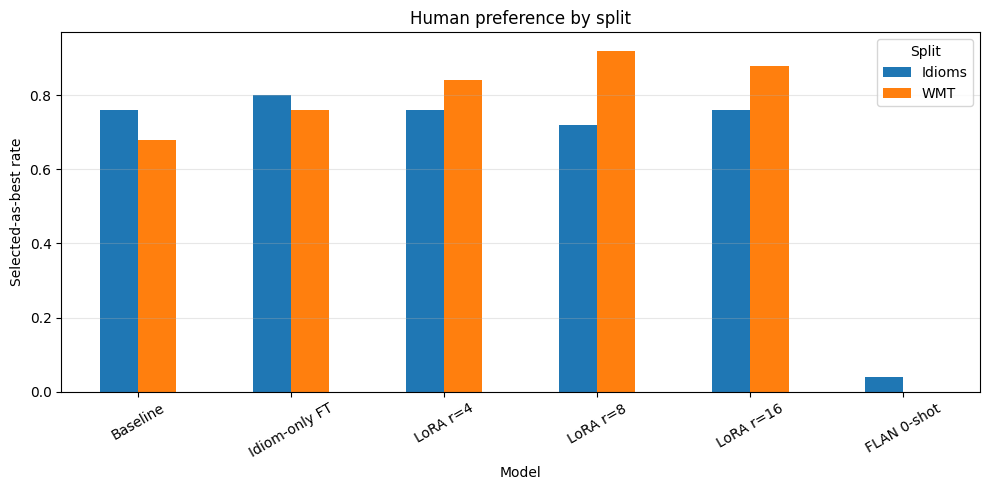

Wrote figure: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/paper_figure_human_quality_by_split.png


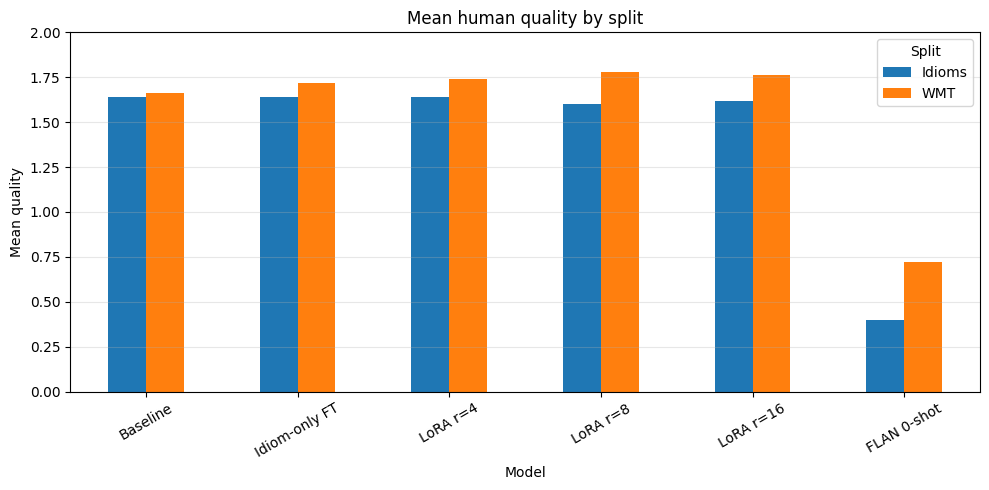

In [21]:
import matplotlib.pyplot as plt


# Figure 1: human preference by split
plot_model_order = [
    'Baseline',
    'Idiom-only FT',
    'LoRA r=4',
    'LoRA r=8',
    'LoRA r=16',
    'FLAN 0-shot',
]

preference_plot_df = paper_plot_human_preference.copy()
preference_plot_df['model'] = pd.Categorical(
    preference_plot_df['model'],
    categories=plot_model_order,
    ordered=True,
)
preference_plot_df['split'] = pd.Categorical(
    preference_plot_df['split'],
    categories=['Idioms', 'WMT'],
    ordered=True,
)
preference_plot_df = preference_plot_df.sort_values(['model', 'split']).reset_index(drop=True)

pref_pivot = preference_plot_df.pivot(index='model', columns='split', values='selected_as_best_rate')
ax = pref_pivot.plot(kind='bar', figsize=(10, 5), rot=30)
ax.set_title('Human preference by split')
ax.set_xlabel('Model')
ax.set_ylabel('Selected-as-best rate')
ax.legend(title='Split')
ax.set_ylim(0, max(0.8, float(np.nanmax(pref_pivot.values)) + 0.05))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
preference_plot_path = EXPORT_DIR / 'paper_figure_human_preference_by_split.png'
try:
    plt.savefig(preference_plot_path, dpi=200, bbox_inches='tight')
    print('Wrote figure:', preference_plot_path)
except Exception as e:
    print('FAILED figure export:', preference_plot_path)
    print(' ', e)
plt.show()

# Figure 2: mean human quality by split
quality_plot_df = paper_plot_human_quality.copy()
quality_plot_df['model'] = pd.Categorical(
    quality_plot_df['model'],
    categories=plot_model_order,
    ordered=True,
)
quality_plot_df['split'] = pd.Categorical(
    quality_plot_df['split'],
    categories=['Idioms', 'WMT'],
    ordered=True,
)
quality_plot_df = quality_plot_df.sort_values(['model', 'split']).reset_index(drop=True)

quality_pivot_plot = quality_plot_df.pivot(index='model', columns='split', values='mean_quality')
ax = quality_pivot_plot.plot(kind='bar', figsize=(10, 5), rot=30)
ax.set_title('Mean human quality by split')
ax.set_xlabel('Model')
ax.set_ylabel('Mean quality')
ax.legend(title='Split')
ax.set_ylim(0, max(2.0, float(np.nanmax(quality_pivot_plot.values)) + 0.1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
quality_plot_path = EXPORT_DIR / 'paper_figure_human_quality_by_split.png'
try:
    plt.savefig(quality_plot_path, dpi=200, bbox_inches='tight')
    print('Wrote figure:', quality_plot_path)
except Exception as e:
    print('FAILED figure export:', quality_plot_path)
    print(' ', e)
plt.show()


## 14. Export paper-ready artifacts

All exported files are written to `results/human_eval_outputs/` inside the project directory.



In [22]:
exports = {
    'human_eval_long.csv': human_long,
    'human_eval_summary_by_split.csv': summary_by_split,
    'human_eval_summary_overall.csv': summary_overall,
    'human_eval_best_output_summary.csv': best_output_summary,
    'human_eval_tie_diagnostics.csv': tie_diagnostics,
    'human_eval_unique_best_summary.csv': unique_best_summary,
    'human_eval_selected_label_summary.csv': selected_label_summary,
    'human_eval_winner_summary.csv': winner_summary,
    'human_eval_pairwise_preference.csv': pairwise_pref,
    'human_eval_bootstrap_adequacy.csv': bootstrap_adequacy,
    'human_eval_bootstrap_fluency.csv': bootstrap_fluency,
    'human_eval_bootstrap_idiom.csv': bootstrap_idiom,
    'human_eval_notes_examples.csv': notes_examples,
    'human_eval_example_rankings.csv': example_rankings,
    'human_eval_quality_pivot.csv': quality_pivot,
    'human_eval_adequacy_pivot.csv': adequacy_pivot,
    'human_eval_fluency_pivot.csv': fluency_pivot,
    'human_eval_idiom_correct_pivot.csv': idiom_correct_pivot,
    'human_eval_over_idiomatization_pivot.csv': over_idiom_pivot,
    'human_eval_vs_automatic_metrics.csv': compare_df,
    'human_eval_vs_comet_agreement.csv': example_level_metric_agreement,
    'paper_table_human_by_split.csv': paper_table_human_by_split,
    'paper_table_human_agreement.csv': paper_table_human_agreement,
    'paper_plot_human_preference.csv': paper_plot_human_preference,
    'paper_plot_human_quality.csv': paper_plot_human_quality,
    'paper_agreement_summary.csv': paper_agreement_summary,
    'paper_example_candidates.csv': paper_example_candidates,
    'paper_example_predictions.csv': paper_example_predictions,
}

failed_exports = []

for filename, df in exports.items():
    out_path = EXPORT_DIR / filename
    try:
        df.to_csv(out_path, index=False)
        print('Wrote:', out_path)
    except Exception as e:
        failed_exports.append((filename, str(e)))
        print('FAILED:', out_path)
        print('  ', e)

print('\nExport complete.')
if failed_exports:
    print('\nFailed exports:')
    for filename, err in failed_exports:
        print(f'- {filename}: {err}')
else:
    print('All files exported successfully.')

print('\nFiles currently present in export directory:')
display(pd.Series(sorted([p.name for p in EXPORT_DIR.iterdir() if p.is_file()]), name='export_file'))


Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_long.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_summary_by_split.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_summary_overall.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_best_output_summary.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_tie_diagnostics.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_unique_best_summary.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_selected_label_summary.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_winner_summary.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_outputs/human_eval_pairwise_preference.csv
Wrote: /content/drive/MyDrive/ds266_idiom_mt/results/human_eval_o

,export_file
0,human_eval_adequacy_pivot.csv
1,human_eval_best_output_summary.csv
2,human_eval_bootstrap_adequacy.csv
3,human_eval_bootstrap_fluency.csv
4,human_eval_bootstrap_idiom.csv
5,human_eval_example_rankings.csv
6,human_eval_fluency_pivot.csv
7,human_eval_idiom_correct_pivot.csv
8,human_eval_long.csv
9,human_eval_notes_examples.csv
